<a href="https://colab.research.google.com/github/marlon-domingues/Darwini/blob/main/Proje%C3%A7%C3%A3o%20financeira%20COTEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# prompt: importe as bibliotecas usuais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
tempo_em_anos = 1
meses = [i for i in range(tempo_em_anos * 12)]
qtd_meses = len(meses)


In [9]:
#projeção da evolução de limpeza em metros quadrados

limpeza_mes1=1000    #quantidade de metros quadrados limpos no primeiro mes de operação
taxa_mensal=1.08     #taxa de crescimento mensal de metros quadrados limpos

metros_limpos=[limpeza_mes1]
qtd_predios=[0]

area_predio=2500    # area quivalente de um predio de

for i in range(qtd_meses-1):
  metros_limpos.append(metros_limpos[-1]*taxa_mensal)  #vetor de quatidade de metros quadrados limpos ao longo do tempo
  qtd_predios.append(metros_limpos[-1]/area_predio)



In [10]:
#projeção do funcionamento da máquina

velocidade_robo=0.25     #velocidade média em metros por segundo do robô
largura_jato=0.5        #largura do jato de agua que atinge a fachada
horas_dia=8             #horas uteis de trabalho por dia
dias_uteis=21           #dias uteis do mes
taxa_operacao=0.5       #porcentagem do tempo util de trabalho que o robo está em operação

metros_hora_robo=velocidade_robo*largura_jato*3600  #metros quadrados limpos em média por um robo em uma hora
metros_mes_robo=metros_hora_robo*horas_dia*dias_uteis*taxa_operacao  #metros pintados em média por um robo no mes

qtd_maquinas=[]         #quantidade de maquinas em operação ao longo do tempo
horas_maquina=[]        #quantidade de horas por mes que as maquinas trabalham

for i in range(qtd_meses):
  qtd_maquinas.append(round(0.5+metros_limpos[i]/metros_mes_robo))
  horas_maquina.append(metros_limpos[i]/metros_hora_robo)


0.9997215035463985


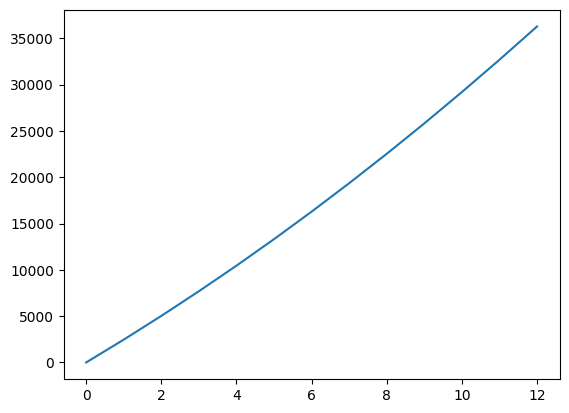

In [11]:
Taxa_base_inicial = 800   #Taxa fixa de utilização da máquina
Taxa_base_final = 5000

Taxa_hora_inicial = 750   #custo por hora máquina utilizado
Taxa_hora_final = 2500

custo_maquina = 35000     #custo de fabricação do robô
custo_manutencao = 2000   #custo de manutenção mensal para cada máquina

tempo_ajuste=60
razao=1

if tempo_ajuste>qtd_meses:
  razao=qtd_meses/tempo_ajuste
  tempo_ajuste=qtd_meses

Taxa_base = np.linspace(Taxa_base_inicial, razao*Taxa_base_final, tempo_ajuste)
Taxa_hora = np.linspace(Taxa_hora_inicial, razao*Taxa_hora_final, tempo_ajuste)

if tempo_ajuste<qtd_meses:
  for i in range(qtd_meses-tempo_ajuste):
    Taxa_base.append(Taxa_base_final)
    Taxa_hora.append(Taxa_hora_final)

Receita_taxa_hora=Taxa_hora*horas_maquina
Receita_taxa_base=Taxa_base*qtd_maquinas

Receita_total=Receita_taxa_base+Receita_taxa_hora

custo_manutenca_maquina=2000

custo_mensal=[]


custo_mensal=custo_manutenca_maquina*qtd_maquinas

lucro_bruto = [r - c for r, c in zip(Receita_total, custo_mensal)]

caixa=[0]

for i in range(qtd_meses):
  caixa.append(caixa[-1]+lucro_bruto[i])

plt.plot(caixa)
plt.show()